In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import numpy as np

from error_prop import propagazione_errore


frac = lambda val: propagazione_errore(["a", "b"] , "a/b" , val , [[np.sqrt(val[0]) , 0] , [0 , np.sqrt(val[1])]] , Display=False)


## Note

- Nei grafici gli errori sono a caso
- Mancano i fattori geometrici

In [2]:
default_dir = str(Path(".").absolute()).split("/Lab-muons")[0]+"/Lab-muons/"
universal_dir = lambda path: default_dir + path

DATA_PATH = universal_dir("Data/calibration/dead_zones.csv")
SIM_PATH = universal_dir("simulazioni/bolde/muons/muon_distribution_simulation_results.csv")

data = pd.read_csv(DATA_PATH, sep=",", header=0)
sim = pd.read_csv(SIM_PATH , sep=",", header=0)
display(data)
display(sim)


,ordine[TtB],p_distanza[cm],g_distanza[cm],m_distanza[cm],p_count,pm_doppie,gm_doppie,pg_doppie,pgm_triple,tempo[min]
0,mpg,0,0,0,9321,7198,5882,NaN,5784,5.0
1,mpg,15,0,0,9478,6597,5907,NaN,4995,5.0
2,mpg,30,0,0,9288,5363,5877,NaN,3743,5.0
3,mpg,45,0,0,9194,4068,5908,NaN,2503,5.0
4,mpg,60,0,0,9472,2761,6146,NaN,1468,5.0
5,mpg,75,0,0,9597,1402,5896,NaN,362,5.0
6,mgp,0,0,0,9405,5926,7188,NaN,5787,5.0
7,mgp,0,15,0,9300,5992,6504,NaN,4996,5.0
8,mgp,0,30,0,9370,6024,5371,NaN,3755,5.0
9,mgp,0,45,0,9127,5954,4039,NaN,2540,5.0


,configuration,Tx,Ty,Tz,Mx,My,Mz,Bx,By,Bz,doppie,triple,flag
0,m g p,0,0,12.8,0,0,8.4,0,0,0,100000,100000,220350
1,m g p,0,0,12.8,15,0,8.4,0,0,0,100000,86755,241544
2,m g p,0,0,12.8,30,0,8.4,0,0,0,100000,66368,269478
3,m g p,0,0,12.8,45,0,8.4,0,0,0,100000,45235,300774
4,m g p,0,0,12.8,60,0,8.4,0,0,0,100000,24607,330099
5,m g p,0,0,12.8,75,0,8.4,0,0,0,100000,4287,357146
6,g m p,0,0,23.0,0,0,12.8,0,0,0,100000,100000,444366
7,g m p,0,0,23.0,15,0,12.8,0,0,0,100000,87700,464504
8,g m p,0,0,23.0,30,0,12.8,0,0,0,100000,66726,498671
9,g m p,0,0,23.0,45,0,12.8,0,0,0,100000,43584,540052


In [3]:
df_P = data[data['ordine[TtB]'] == 'mpg']
df_G = data[data['ordine[TtB]'] == 'mgp']
df_M = data[data['ordine[TtB]'] == 'gmp']

display( df_P)

,ordine[TtB],p_distanza[cm],g_distanza[cm],m_distanza[cm],p_count,pm_doppie,gm_doppie,pg_doppie,pgm_triple,tempo[min]
0,mpg,0,0,0,9321,7198,5882,NaN,5784,5.0
1,mpg,15,0,0,9478,6597,5907,NaN,4995,5.0
2,mpg,30,0,0,9288,5363,5877,NaN,3743,5.0
3,mpg,45,0,0,9194,4068,5908,NaN,2503,5.0
4,mpg,60,0,0,9472,2761,6146,NaN,1468,5.0
5,mpg,75,0,0,9597,1402,5896,NaN,362,5.0


# Misure

In [4]:
fig = go.Figure()

fig.add_trace( go.Scatter( x = df_P['p_distanza[cm]'] , y = ((df_P[' pgm_triple'])/(df_P[' gm_doppie'])) , mode = 'markers' , name = 'p_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(df_P['p_distanza[cm]']) , visible = True)))


fig.add_trace( go.Scatter( x = df_G['g_distanza[cm]'] , y = ((df_G[' pgm_triple'])/(df_G[' pm_doppie'])) , mode = 'markers' , name = 'g_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(df_G['g_distanza[cm]']) , visible = True)))

fig.add_trace( go.Scatter( x = df_M['m_distanza[cm]'] , y = ((df_M[' pgm_triple'])/(df_M[' pg_doppie'])) , mode = 'markers' , name = 'g_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(df_M['m_distanza[cm]']) , visible = True)))


fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'rate triple/doppie')
fig.show()

# Simulazione

In [5]:
sim_P = sim[sim['configuration'] == 'm g p']
sim_G = sim[sim['configuration'] == 'm g p']
sim_M = sim[sim['configuration'] == 'g m p']

sim_M_1 = sim_M[sim_M['Tz'] == 23.0]
sim_M_2 = sim_M[sim_M['Tz'] == 25.3]

display(sim_P)
display(sim_M_1)

,configuration,Tx,Ty,Tz,Mx,My,Mz,Bx,By,Bz,doppie,triple,flag
0,m g p,0,0,12.8,0,0,8.4,0,0,0,100000,100000,220350
1,m g p,0,0,12.8,15,0,8.4,0,0,0,100000,86755,241544
2,m g p,0,0,12.8,30,0,8.4,0,0,0,100000,66368,269478
3,m g p,0,0,12.8,45,0,8.4,0,0,0,100000,45235,300774
4,m g p,0,0,12.8,60,0,8.4,0,0,0,100000,24607,330099
5,m g p,0,0,12.8,75,0,8.4,0,0,0,100000,4287,357146


,configuration,Tx,Ty,Tz,Mx,My,Mz,Bx,By,Bz,doppie,triple,flag
6,g m p,0,0,23.0,0,0,12.8,0,0,0,100000,100000,444366
7,g m p,0,0,23.0,15,0,12.8,0,0,0,100000,87700,464504
8,g m p,0,0,23.0,30,0,12.8,0,0,0,100000,66726,498671
9,g m p,0,0,23.0,45,0,12.8,0,0,0,100000,43584,540052
10,g m p,0,0,23.0,60,0,12.8,0,0,0,100000,20689,581601
11,g m p,0,0,23.0,75,0,12.8,0,0,0,100000,2111,617436


In [6]:
fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_P['Mx'] , y = ((sim_P['triple'])/(sim_P['doppie'])) , mode = 'markers' , name = 'p_sim_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(sim_P['Mx']) , visible = True)))


fig.add_trace( go.Scatter( x = sim_M['Mx'] , y = ((sim_M['triple'])/(sim_M['doppie'])) , mode = 'markers' , name = 'M_sim_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(sim_M['Mx']) , visible = True)))

fig.add_trace( go.Scatter( x = sim_G['Mx'] , y = ((sim_G['triple'])/(sim_G['doppie'])) , mode = 'markers' , name = 'g_sim_efficiency' , error_y = dict( type='data' , array=0.1*np.ones_like(sim_G['Mx']) , visible = True)))


fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'rate triple/doppie')
fig.show()

# Partenope

In [7]:
tP_S = np.array(sim_P['triple'])
dP_S = np.array(sim_P['doppie'])
tP = np.array(df_P[' pgm_triple'])
dP = np.array(df_P[' gm_doppie'])

err_data = [float(frac([tP[i], dP[i]])) for i in range(len(tP))]
err_sim = [float(frac([tP_S[i], dP_S[i]])) for i in range(len(tP_S))]

fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_P['Mx'] , y = ((sim_P['triple'])/(sim_P['doppie'])) , mode = 'markers' , name = 'P' , error_y = dict( type='data' , array=err_sim , visible = True)))

fig.add_trace( go.Scatter( x = df_P['p_distanza[cm]'] , y = ((df_P[' pgm_triple'])/(df_P[' gm_doppie'])) , mode = 'markers' , name = 'P_data' , error_y = dict( type='data' , array=err_data , visible = True)))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'rate triple/doppie')
fig.show()


## diff

In [8]:
fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_P['Mx'] , y = -((df_P[' pgm_triple'])/(df_P[' gm_doppie']) - (sim_P['triple'].to_numpy())/(sim_P['doppie'].to_numpy())) , mode = 'markers' , name = 'P'))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'diff sim-data')
fig.show()

# Giunone

In [9]:
tG_S = np.array(sim_G['triple'])
dG_S = np.array(sim_G['doppie'])
tG = np.array(df_G[' pgm_triple'])
dG = np.array(df_G[' pm_doppie'])

err_data = [ float(frac([tG[i], dG[i]])) for i in range(len(tG))]
err_sim = [ float(frac([tG_S[i], dG_S[i]])) for i in range(len(tG_S))]

fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_G['Mx'] , y = ((sim_G['triple'])/(sim_G['doppie'])) , mode = 'markers' , name = 'G' , error_y = dict( type='data' , array=err_sim, visible = True)))

fig.add_trace( go.Scatter( x = df_G['g_distanza[cm]'] , y = ((df_G[' pgm_triple'])/(df_G[' pm_doppie'])) , mode = 'markers' , name = 'G_data' , error_y = dict( type='data' , array=err_data , visible = True)))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'rate triple/doppie')
fig.show()

## Diff

In [10]:
fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_G['Mx'] , y = -(((df_G[' pgm_triple'])/(df_G[' pm_doppie'])) - ((sim_G['triple'].to_numpy())/(sim_G['doppie'].to_numpy()))) , mode = 'markers' , name = 'G'))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'diff sim-data')
fig.show()

# Minerva

In [11]:
tM_S = np.array(sim_M['triple'])
dM_S = np.array(sim_M['doppie'])
tM = np.array(df_M[' pgm_triple'])
dM = np.array(df_M[' pg_doppie'])

err_data = [ float(frac([tM[i], dM[i]])) for i in range(len(tM))]
err_sim = [ float(frac([tM_S[i], dM_S[i]])) for i in range(len(tM_S))]

err_sim1 = err_sim[:len(sim_M_1["Mx"]):]
err_sim2 = err_sim[len(sim_M_1["Mx"])::]

fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_M_1['Mx'] , y = ((sim_M_1['triple'])/(sim_M_1['doppie'])) , mode = 'markers' , name = 'M1' , error_y = dict( type='data' , array=err_sim1 , visible = True)))

fig.add_trace( go.Scatter( x = sim_M_2['Mx'] , y = ((sim_M_2['triple'])/(sim_M_2['doppie'])) , mode = 'markers' , name = 'M2' , error_y = dict( type='data' , array=err_sim2 , visible = True)))

fig.add_trace( go.Scatter( x = df_M['m_distanza[cm]'] , y = ((df_M[' pgm_triple'])/(df_M[' pg_doppie'])) , mode = 'markers' , name = 'M_data' , error_y = dict( type='data' , array=err_data , visible = True)))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'rate triple/doppie')
fig.show()

## Diff

In [12]:
fig = go.Figure()

fig.add_trace( go.Scatter( x = sim_M_1['Mx'] , y = -((df_M[' pgm_triple'])/(df_M[' pg_doppie']) - (sim_M_1['triple'].to_numpy())/(sim_M_1['doppie'].to_numpy())) , mode = 'markers' , name = 'M1'))

fig.add_trace( go.Scatter( x = sim_M_2['Mx'] , y = -((df_M[' pgm_triple'])/(df_M[' pg_doppie']) - (sim_M_2['triple'].to_numpy())/(sim_M_2['doppie'].to_numpy())) , mode = 'markers' , name = 'M2'))

fig.update_xaxes( title_text = 'distanza[cm]')
fig.update_yaxes( title_text = 'diff sim-data')
fig.show()

# new

In [13]:
final_df = pd.read_csv('/home/matti/uni/lab/Lab-muons/Data/calibration/efficiency.csv', delimiter = ',')
# print(final_df.columns)
minerva = final_df[final_df['ordine[TtB]'] == 'pmg'][[' pg_doppie', ' pgm_triple']].values.tolist()
partenope = final_df[final_df['ordine[TtB]'] == 'mpg'][[' gm_doppie', ' pgm_triple']].values.tolist()
giunone = final_df[final_df['ordine[TtB]'] == 'mgp'][[' pm_doppie', ' pgm_triple']].values.tolist()
print (minerva, '\n',partenope, '\n', giunone)

[[3214.0, 1792.0], [3245.0, 1514.0], [3223.0, 1228.0], [3288.0, 809.0], [3326.0, 362.0]] 
 [[2103.0, 2073.0], [2150.0, 1800.0], [2182.0, 1330.0], [2100.0, 975.0], [2136.0, 533.0]] 
 [[271.0, 264.0], [250.0, 181.0], [276.0, 169.0], [293.0, 130.0], [263.0, 74.0]]


## p

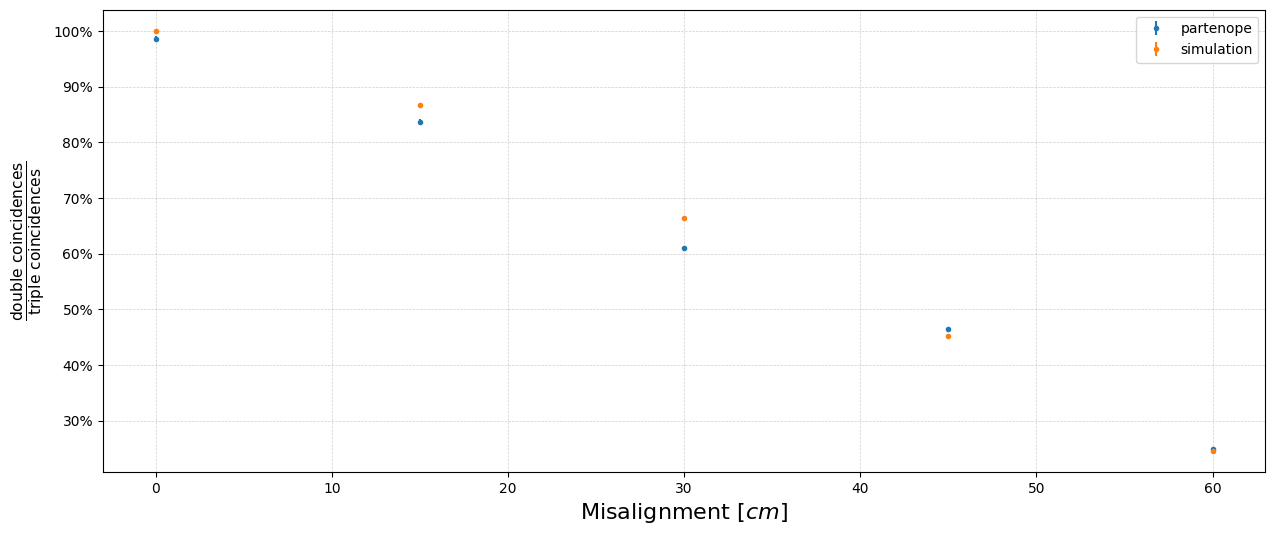

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
x = (0, 15, 30, 45, 60)
y_minerva = [pair[1] / pair[0] for pair in minerva]
y_partenope = [pair[1] / pair[0] for pair in partenope]
y_giunone = [pair[1] / pair[0] for pair in giunone]


figsize = 15, 6

fig, (ax1) = plt.subplots(1, figsize= figsize)

ax1.set_ylabel(r'$\frac{\text{double coincidences}}{\text{triple coincidences}}$', fontsize = 16)
ax1.set_xlabel('Misalignment $[cm]$', fontsize = 16)
err_y_part = [float(frac([partenope[i][1], partenope[i][0]])) for i in range(len(partenope))]
err_part_sim = [float(frac([sim_P['triple'][i], sim_P['doppie'][i]])) for i in range(5)]
size = 200
error_multi = 1
for i in range(5):
    err_part_sim[i] = err_part_sim[i] * error_multi
    err_y_part[i] = err_y_part[i] * error_multi
ax1.errorbar(x, y_partenope, err_y_part, label='partenope', linestyle='none', fmt = '.')
ax1.errorbar(x, ((sim_P['triple'][:5].values)/(sim_P['doppie'][:5].values)), (err_part_sim ), label='simulation', linestyle='none',fmt = '.')

# ax1.text(x=0.99, y=0.99, s=f'errors are multiplied by ${error_multi}$',
#          transform=ax1.transAxes, ha='right', va='top',
#          fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend()
# print(partenope[0][1]/ partenope[0][0], (sim_P['triple'][0])/(sim_P['doppie'][0]))
# print( y_minerva)
# plt.savefig('partenope_resolution.pdf')

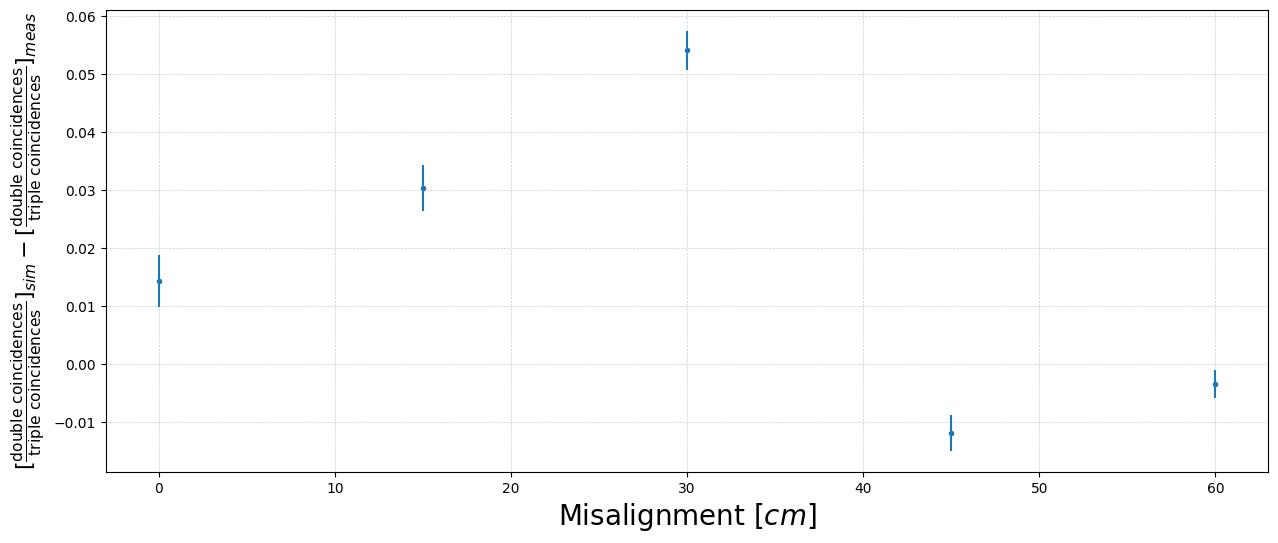

In [15]:
diff = np.zeros(5)
err_diff = np.zeros(5)
for i in range (5):
    diff[i] = ((sim_P['triple'].iloc[i])/(sim_P['doppie'].iloc[i])) - y_partenope[i]
    err_diff[i] = np.sqrt((err_y_part[i])**2 +( err_part_sim[i])**2)

fig, (ax1) = plt.subplots(1, figsize= figsize)
ax1.errorbar(x, diff, err_diff, linestyle = 'none', fmt = '.')
ax1.set_ylabel(r'$[\frac{\text{double coincidences}}{\text{triple coincidences}}]_{sim} - [\frac{\text{double coincidences}}{\text{triple coincidences}}]_{meas}$',
               fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$', fontsize = 20)
# ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
# plt.savefig('p_res_diff.pdf')
# ax1.legend()

In [16]:
print(diff[3]/err_diff[3])

-3.9037710788462343


## g

il seguente è fatto con i dati nuovi, il discriminatore non lavorava tanto bene e avevamo rate non compatibili con i nostri, probabilmente è sbagliata tutta la presa dati

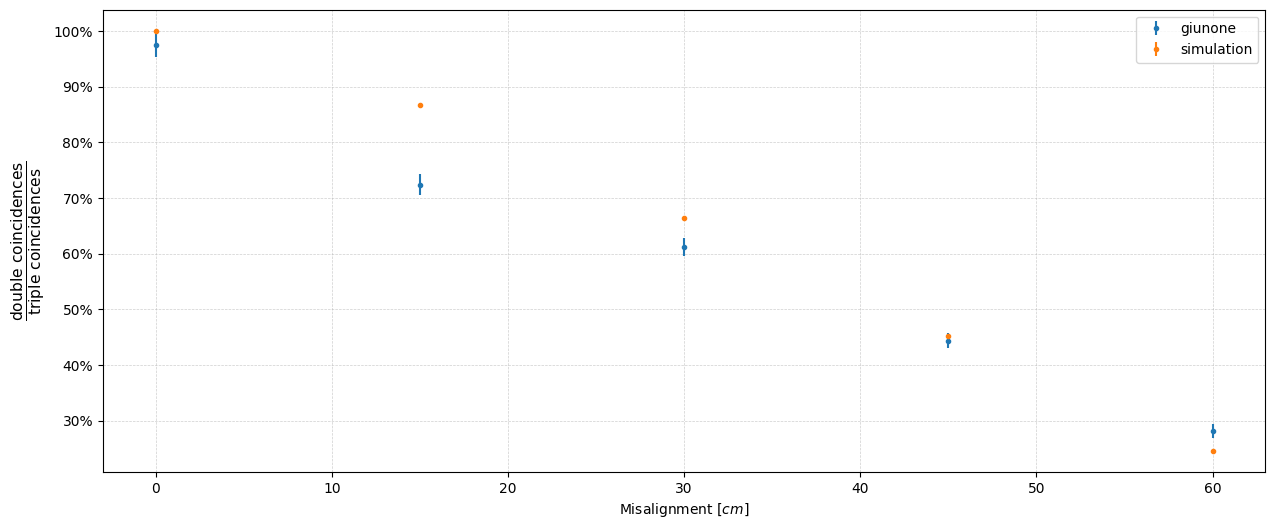

In [28]:
fig, (ax1) = plt.subplots(1, figsize= figsize)

ax1.set_ylabel(r'$\frac{\text{double coincidences}}{\text{triple coincidences}}$', fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$')
err_y_part = [float(frac([giunone[i][1], giunone[i][0]])) for i in range(len(giunone))]
err_part_sim = [float(frac([sim_G['triple'][i], sim_G['doppie'][i]])) for i in range(5)]
size = 200
error_multi = 1
for i in range(5):
    err_part_sim[i] = err_part_sim[i] * error_multi
    err_y_part[i] = err_y_part[i] * error_multi
ax1.errorbar(x, y_giunone, err_y_part, label='giunone', linestyle='none', fmt = '.')
ax1.errorbar(x, ((sim_G['triple'][:5].values)/(sim_G['doppie'][:5].values)), (err_part_sim ), label='simulation', linestyle='none',fmt = '.')

# ax1.text(x=0.99, y=0.99, s=f'errors are multiplied by ${error_multi}$',
#          transform=ax1.transAxes, ha='right', va='top',
#          fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend()

# print(giunone[0][1]/ giunone[0][0], (sim_P['triple'][0])/(sim_P['doppie'][0]))
# print( err_part_sim )
# plt.savefig('giunone_resolution.pdf')

il seguente è fatto con i dati presi in precedenza, è buono con valori a livello di numero di conteggi compatibili con gli altri scintillatori.

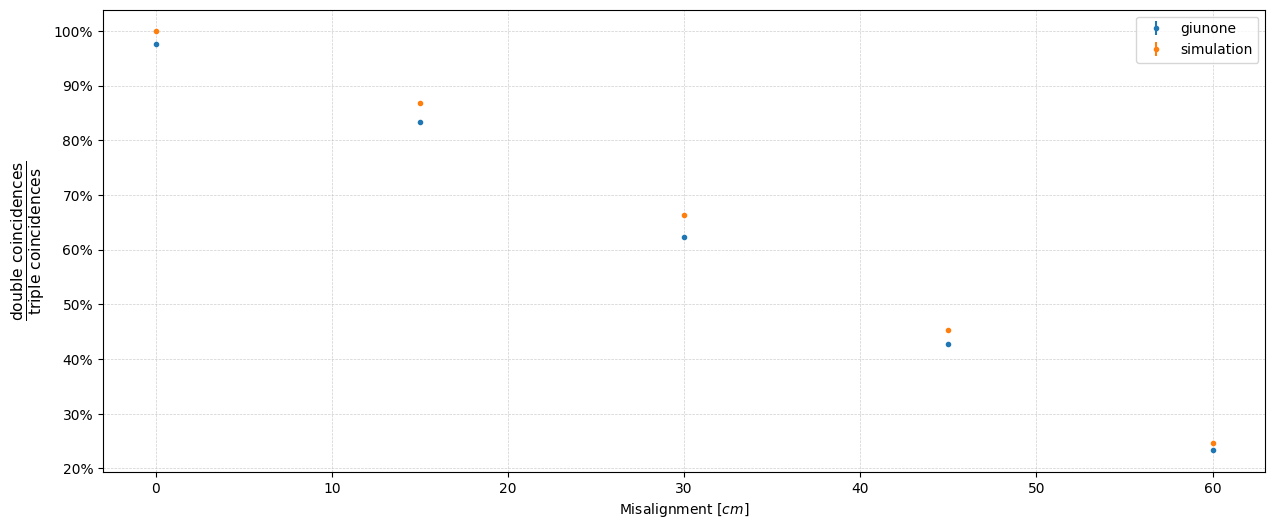

In [29]:
fig, (ax1) = plt.subplots(1, figsize= figsize)
err_data = [ float(frac([tG[:5][i], dG[:5][i]])) for i in range(len(tG)-1)]
# x = sim_G['Mx'] , 
# y = ((sim_G['triple'])/(sim_G['doppie']))
y = ((df_G[' pgm_triple'][:5])/(df_G[' pm_doppie'][:5]))

ax1.set_ylabel(r'$\frac{\text{double coincidences}}{\text{triple coincidences}}$',fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$')
err_part_sim = [float(frac([sim_G['triple'][i], sim_G['doppie'][i]])) for i in range(5)]
size = 200
error_multi = 1
for i in range(5):
    err_part_sim[i] = err_part_sim[i] * error_multi
    err_data[i] = err_data[i] * error_multi
ax1.errorbar(x, y, err_data, label='giunone', linestyle='none', fmt = '.')
ax1.errorbar(x, ((sim_G['triple'][:5].values)/(sim_G['doppie'][:5].values)), (err_part_sim ), label='simulation', linestyle='none',fmt = '.')

# ax1.text(x=0.99, y=0.99, s=f'errors are multiplied by ${error_multi}$',
#          transform=ax1.transAxes, ha='right', va='top',
#          fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
ax1.legend()

# print(giunone[0][1]/ giunone[0][0], (sim_P['triple'][0])/(sim_P['doppie'][0]))
# print( err_part_sim )
# plt.savefig('giunone_resolution_old.pdf')

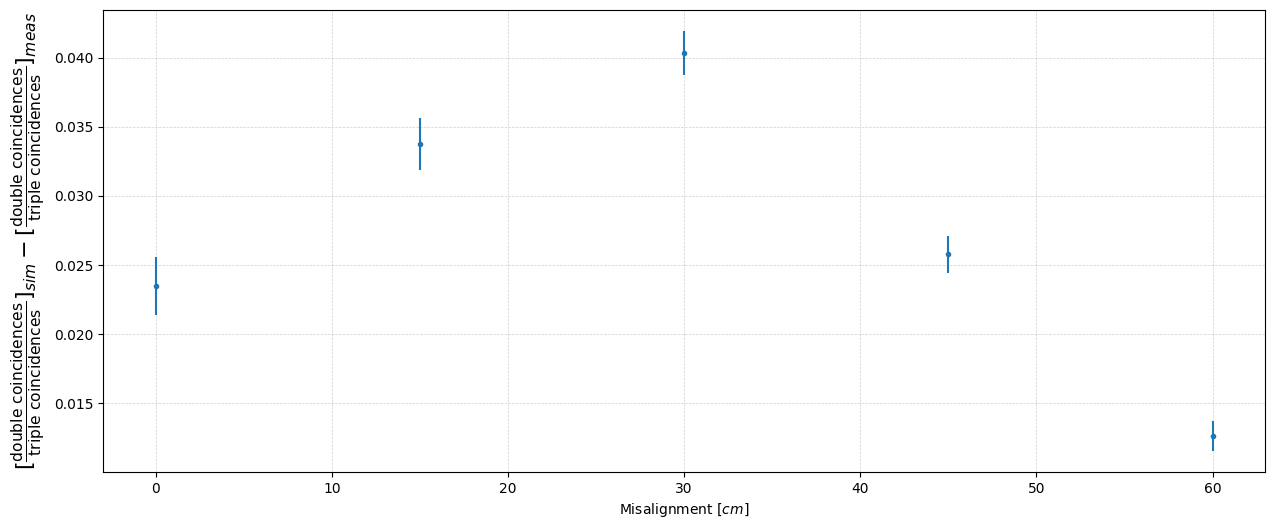

In [30]:
diff = np.zeros(5)
err_diff = np.zeros(5)
for i in range (5):
    diff[i] = ((sim_G['triple'].iloc[i])/(sim_G['doppie'].iloc[i])) - y.iloc[i]
    err_diff[i] = np.sqrt((err_data[i])**2 +( err_part_sim[i])**2)

fig, (ax1) = plt.subplots(1, figsize= figsize)
ax1.errorbar(x, diff, err_diff, linestyle = 'none', fmt = '.')
ax1.set_ylabel(r'$[\frac{\text{double coincidences}}{\text{triple coincidences}}]_{sim} - [\frac{\text{double coincidences}}{\text{triple coincidences}}]_{meas}$',
               fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$')
# ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
# plt.savefig('g_res_diff.pdf')
# ax1.legend()

## m

quello che segue è con i dati nuovi

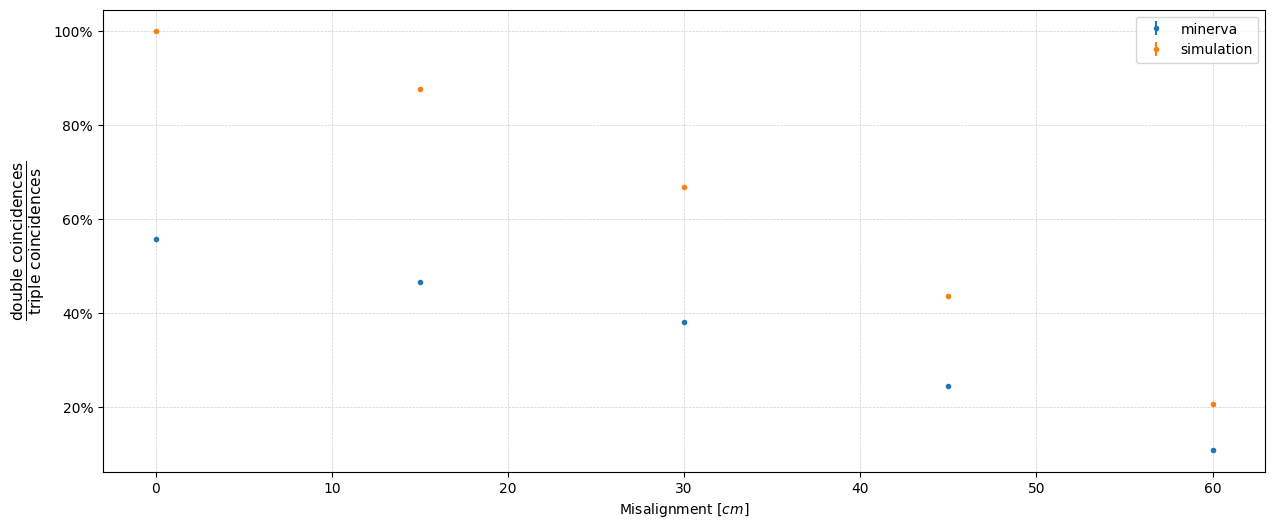

In [31]:
figsize = 15, 6

fig, (ax1) = plt.subplots(1, figsize= figsize)

ax1.set_ylabel(r'$\frac{\text{double coincidences}}{\text{triple coincidences}}$',fontsize = 16)
ax1.set_xlabel('Misalignment $[cm]$')
err_y_min = [float(frac([minerva[i][1], minerva[i][0]])) for i in range(len(minerva))]
err_part_sim = [float(frac([sim_M_2.iloc[i]['triple'], sim_M_2.iloc[i]['doppie']])) for i in range(5)]
size = 200
error_multi = 1
for i in range(5):
    err_part_sim[i] = err_part_sim[i] * error_multi
    err_y_min[i] = err_y_min[i] * error_multi
ax1.errorbar(x, y_minerva, err_y_min, label='minerva', linestyle='none', fmt = '.')
ax1.errorbar(x, ((sim_M_1['triple'][:5].values)/(sim_M_1['doppie'][:5].values)), (err_part_sim ), label='simulation', linestyle='none',fmt = '.')

# ax1.text(x=0.99, y=0.99, s=f'errors are multiplied by ${error_multi}$',
#          transform=ax1.transAxes, ha='right', va='top',
#          fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend()
# print(minerva[0][1]/ minerva[0][0], (sim_P['triple'][0])/(sim_P['doppie'][0]))
# print( err_part_sim )
# plt.savefig('minerva_resolution.pdf')

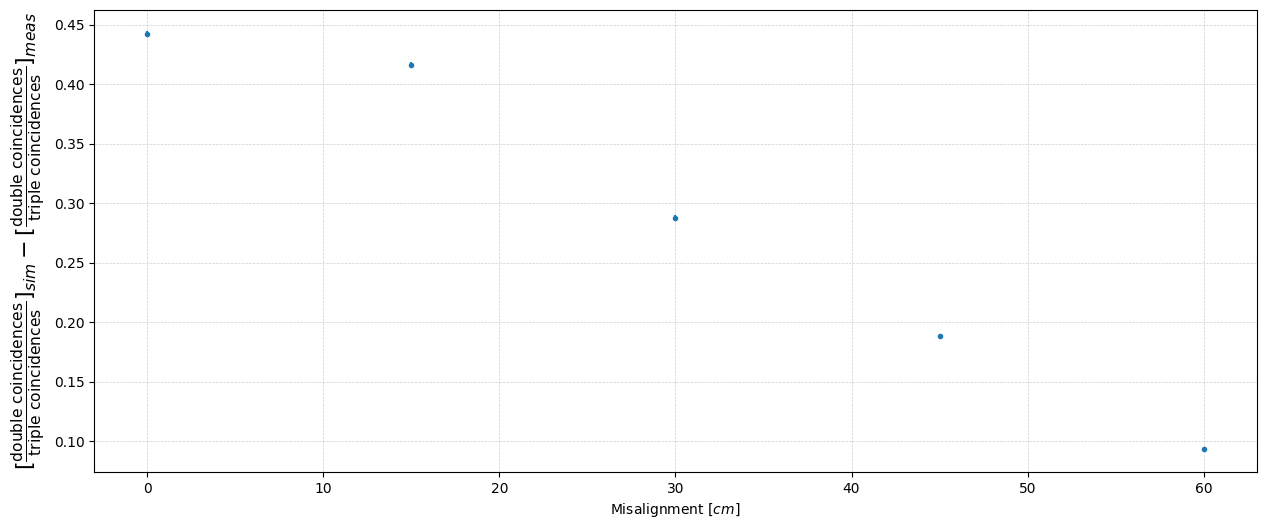

In [32]:
diff = np.zeros(5)
err_diff = np.zeros(5)
for i in range (5):
    diff[i] = ((sim_M_2['triple'].iloc[i])/(sim_M_2['doppie'].iloc[i])) - y_minerva[i]
    err_diff[i] = np.sqrt((err_y_min[i])**2 +( err_part_sim[i])**2)

fig, (ax1) = plt.subplots(1, figsize= figsize)
ax1.errorbar(x, diff, err_diff, linestyle = 'none', fmt = '.')
ax1.set_ylabel(r'$[\frac{\text{double coincidences}}{\text{triple coincidences}}]_{sim} - [\frac{\text{double coincidences}}{\text{triple coincidences}}]_{meas}$',
               fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$')
# ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
# ax1.legend()

ora i dati vecchi

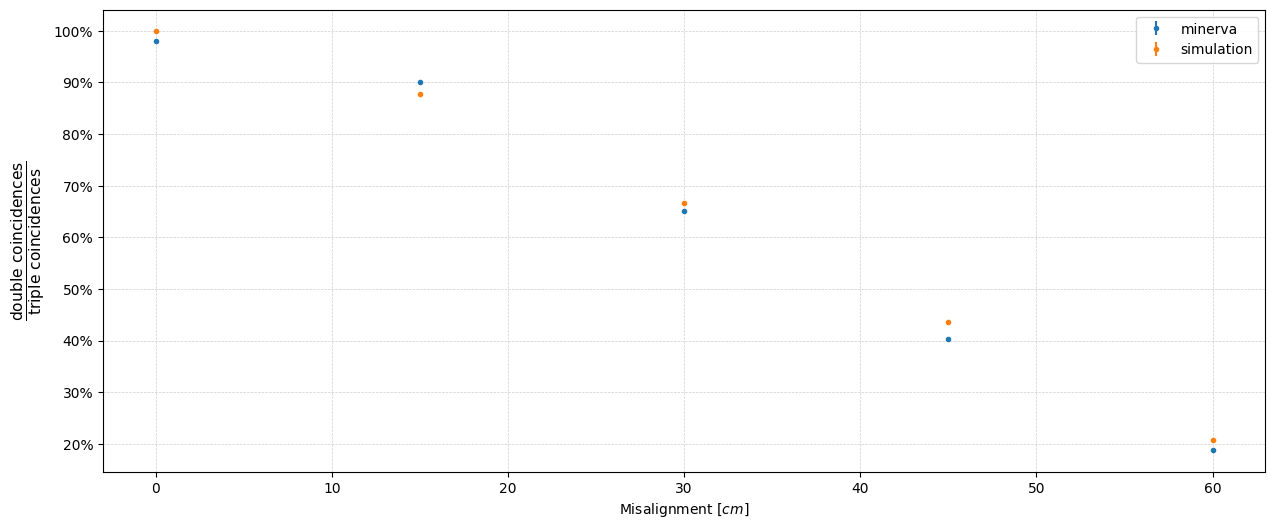

In [33]:
figsize = 15, 6

y = ((df_M[' pgm_triple'][:5])/(df_M[' pg_doppie'][:5])).tolist()

fig, (ax1) = plt.subplots(1, figsize= figsize)

ax1.set_ylabel(r'$\frac{\text{double coincidences}}{\text{triple coincidences}}$', fontsize = 16)
ax1.set_xlabel('Misalignment $[cm]$')
err_y_min = [float(frac([df_M.iloc[i][' pgm_triple'], df_M.iloc[i][' pg_doppie']])) for i in range (5)]
err_part_sim = [float(frac([sim_M_2.iloc[i]['triple'], sim_M_2.iloc[i]['doppie']])) for i in range(5)]
size = 200
error_multi = 1
for i in range(5):
    err_part_sim[i] = err_part_sim[i] * error_multi
    err_y_min[i] = err_y_min[i] * error_multi
ax1.errorbar(x, y, err_y_min, label='minerva', linestyle='none', fmt = '.')
ax1.errorbar(x, ((sim_M_1['triple'][:5].values)/(sim_M_1['doppie'][:5].values)), (err_part_sim ), label='simulation', linestyle='none',fmt = '.')

# ax1.text(x=0.99, y=0.99, s=f'errors are multiplied by ${error_multi}$',
#          transform=ax1.transAxes, ha='right', va='top',
#          fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend()
# print(minerva[0][1]/ minerva[0][0], (sim_P['triple'][0])/(sim_P['doppie'][0]))
# print( err_part_sim )
# plt.savefig('minerva_resolution.pdf')
# print(y)

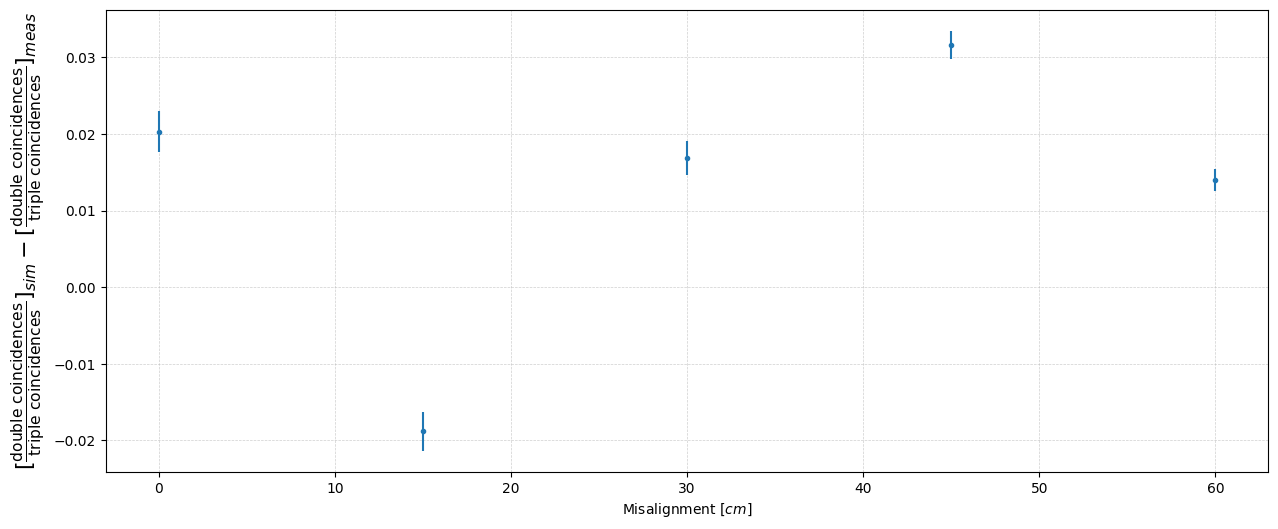

In [34]:

diff = np.zeros(5)
err_diff = np.zeros(5)
for i in range (5):
    diff[i] = ((sim_M_2['triple'].iloc[i])/(sim_M_2['doppie'].iloc[i])) - y[i]
    err_diff[i] = np.sqrt((err_y_min[i])**2 +( err_part_sim[i])**2)

fig, (ax1) = plt.subplots(1, figsize= figsize)
ax1.errorbar(x, diff, err_diff, linestyle = 'none', fmt = '.')
ax1.set_ylabel(r'$[\frac{\text{double coincidences}}{\text{triple coincidences}}]_{sim} - [\frac{\text{double coincidences}}{\text{triple coincidences}}]_{meas}$',
               fontsize = 16)
ax1.set_xlabel(r'Misalignment $[cm]$')
# ax1.yaxis.set_major_formatter(PercentFormatter(xmax = 1))
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6,)
# plt.savefig('m_res_diff.pdf')

In [24]:
print(diff[1]/err_diff[1])

-7.488216541699018
